In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

In [9]:
pt = 'results/*.csv'
csv_files = ('/home/user/projects/FedCore/FedCore/validation_experiment/results/prune_050_res.csv', '/home/user/projects/FedCore/FedCore/validation_experiment/results/no_prune_res.csv', '/home/user/projects/FedCore/FedCore/validation_experiment/results/prune_075_res.csv')
csv_files = sorted(csv_files)
print(f"Found {len(csv_files)} files:")
for file in csv_files:
    print(f"  - {os.path.basename(file)}")

Found 3 files:
  - no_prune_res.csv
  - prune_050_res.csv
  - prune_075_res.csv


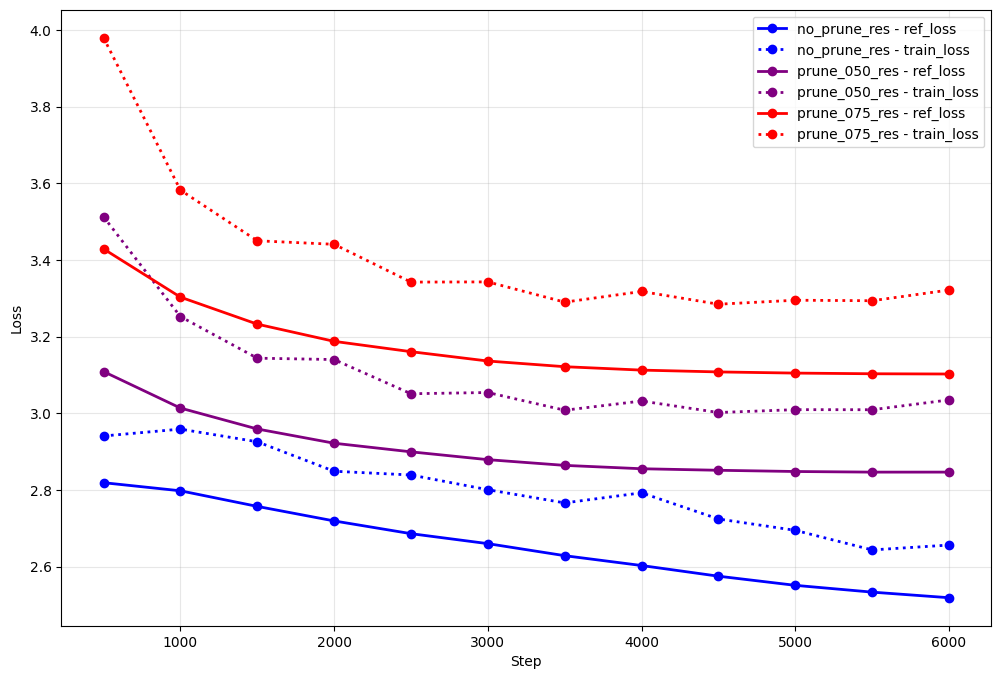

In [10]:
plt.figure(figsize=(12, 8))

total_files = len(csv_files)

for i, file in enumerate(csv_files):
    df = pd.read_csv(file)
    filename = os.path.splitext(os.path.basename(file))[0]
    if total_files <= 1:
        color = (0, 0, 1) 
    else:
        t = i / (total_files - 1)
        r = t                   
        g = 0                     
        b = 1 - t                
        color = (r, g, b)
    plt.plot(df['step'], df['ref_loss'], 
             label=f'{filename} - ref_loss', 
             linestyle='-',
             marker='o',
             color=color, 
             linewidth=2)
    
    plt.plot(df['step'], df['train_loss'], 
             label=f'{filename} - train_loss', 
             linestyle=':',
             marker='o',
             color=color,
             linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [ ]:
plt.figure(figsize=(12, 8))
labels = ['No pruning', '50% pruning', '60% pruning']

total_files = len(csv_files)

for i, file in enumerate(csv_files):
    df = pd.read_csv(file)
    label_name = labels[i]
    filename = os.path.splitext(os.path.basename(file))[0]
    if total_files <= 1:
        color = (0, 0, 1) 
    else:
        t = i / (total_files - 1)
        r = t                   
        g = 0                     
        b = 1 - t                
        color = (r, g, b)
    plt.plot(df['step'], df['ref_loss'], 
             label=f'{label_name} - ref_loss', 
             linestyle='-',
             marker='o',
             color=color, 
             linewidth=2)
    
    plt.plot(df['step'], df['train_loss'], 
             label=f'{label_name} - train_loss', 
             linestyle=':',
             marker='o',
             color=color,
             linewidth=2)

plt.grid(True, alpha=0.3)
plt.legend()
plt.xlabel('Step')
plt.ylabel('Loss')
plt.show()

In [26]:
ntrees = [  45,   95,  195,  245,  295,  345]
print(len(ntrees))
f1 = [0.74177006, 0.76122441, 0.78161108, 0.93899652, 0.94748557, 0.95196782]
print(len(f1))


6
6


In [51]:
n = [  45,   95,  195,  245,  295,  345]

f = [0.40059297, 0.56272607, 0.67760651, 0.71463594,
       0.74177006, 0.76122441]

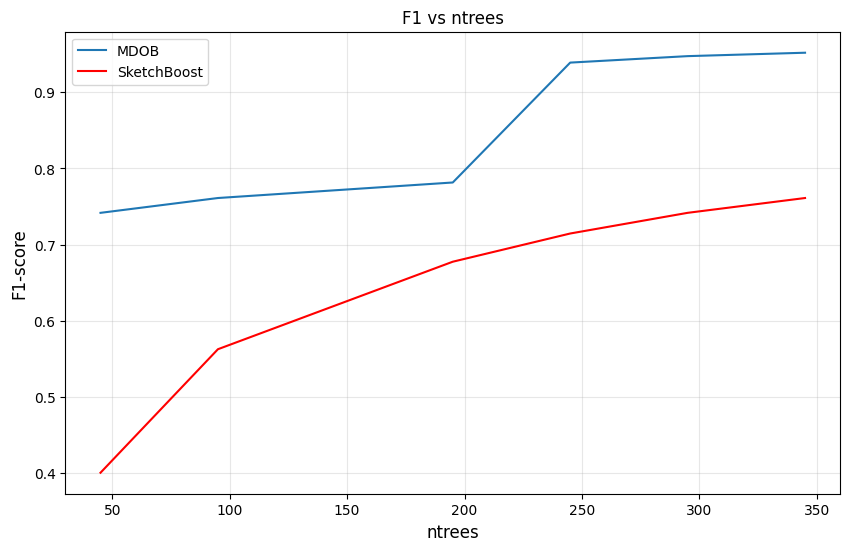

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(ntrees, f1, label='MDOB')
plt.title('F1 vs ntrees')

plt.grid(True, alpha=0.3)

plt.plot(n, f, label='SketchBoost', color='red')
plt.xlabel('ntrees', fontsize=12)
plt.ylabel('F1-score', fontsize=12)
plt.legend()
plt.show()